# TP1 — Análisis previo de los datos

Análisis exploratorio previo a la construcción de los modelos, extraído de `TP1 ramiro.ipynb`.

El objetivo del TP es predecir el peso del bebé al nacer (`weight`, en libras). Este notebook incluye:

- Distribución de la variable a predecir (estadísticos, tests de normalidad, histograma).
- Distribución de los predictores numéricos (`fage`, `mage`, `visits`, `gained`) y categóricos (`mature`, `sex`, `habit`, `marital`, `whitemom`).
- Análisis del peso según cada predictor categórico (boxplots + t-tests).
- Correlación de cada predictor numérico con el peso (scatters + Pearson).
- **Gráficos 3D**: peso del bebé (eje Y) contra todas las combinaciones de las variables numéricas.

Los datos (`X_train.csv`, `y_train.csv`, `X_test.csv`) están en la misma carpeta que este notebook, por lo que se cargan por ruta relativa.

# Carga de los datos

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Armado de los DataFrames:
predictores = pd.read_csv("X_train.csv")
var_ind = pd.read_csv("y_train.csv")["weight"]
X_test = pd.read_csv("X_test.csv")

print("--- Predictores:")
print(predictores)
print("\n--- Variable independiente:")
print(var_ind)

--- Predictores:
     fage  mage       mature  visits  gained     sex      habit      marital  \
0    34.0    34  younger mom    14.0    28.0    male  nonsmoker      married   
1    36.0    31  younger mom    12.0    41.0  female  nonsmoker      married   
2    37.0    36   mature mom    10.0    28.0  female  nonsmoker      married   
3    32.0    31  younger mom    12.0    48.0  female  nonsmoker      married   
4    32.0    26  younger mom    14.0    45.0  female  nonsmoker      married   
..    ...   ...          ...     ...     ...     ...        ...          ...   
670  36.0    31  younger mom    15.0    28.0    male  nonsmoker  not married   
671  33.0    26  younger mom    13.0    34.0  female  nonsmoker      married   
672  37.0    31  younger mom     8.0    33.0  female  nonsmoker      married   
673  27.0    27  younger mom     7.0    25.0  female  nonsmoker      married   
674  21.0    17  younger mom    12.0    41.0  female  nonsmoker  not married   

      whitemom  
0    

# Exploración de los datos: distribución del peso de los bebés al nacer

Estadísticos y verificación de normalidad por los tests de Kolmogorov-Smirnov y Shapiro-Wilk.

In [2]:
media = np.mean(var_ind)
varianza = np.var(var_ind)
desviacion = np.std(var_ind)
mediana = np.median(var_ind)

print("- Media:", media)
print("- Mediana:", mediana)
print("- Varianza:", varianza)
print("- Desviación estándar:", desviacion)

resultado = stats.kstest(
    var_ind,
    stats.norm(np.mean(var_ind), np.std(var_ind)).cdf
)

print("- Estadístico K-S:", resultado.statistic)
print("- p-valor:", resultado.pvalue)

resultado = stats.shapiro(var_ind)

print("\n- Estadístico Shapiro-Wilk:", resultado.statistic)
print("- p-valor:", resultado.pvalue)

print("\nEn ambos tests, el p-value resulta < 0,05, por lo que se rechaza la hipótesis nula que plantea que los datos siguen una distribución normal.")

- Media: 7.2657185185185185
- Mediana: 7.31
- Varianza: 1.475578854101509
- Desviación estándar: 1.214734067235092
- Estadístico K-S: 0.05706290442253159
- p-valor: 0.02369477301048961

- Estadístico Shapiro-Wilk: 0.9691337450125208
- p-valor: 1.0011989237450919e-10

En ambos tests, el p-value resulta < 0,05, por lo que se rechaza la hipótesis nula que plantea que los datos siguen una distribución normal.


## Histograma

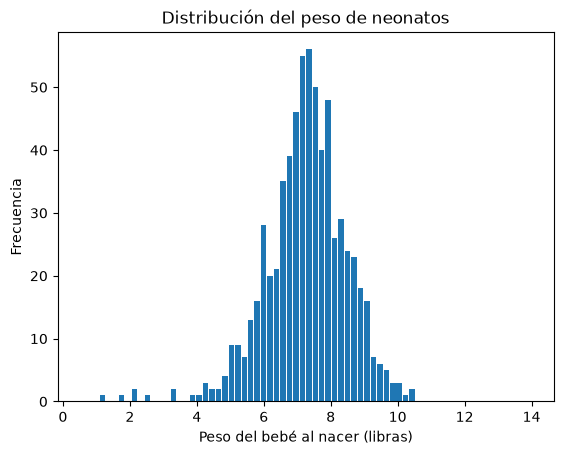

Visualmente, el histograma se aproxima a una distribución normal. Es bastante simétrico, algo que también se interpreta al comparar la media con la mediana.


In [3]:
plt.hist(var_ind, bins=70, range=[0.5, 14], rwidth=0.85)

plt.xlabel("Peso del bebé al nacer (libras)")
plt.ylabel("Frecuencia")
plt.title("Distribución del peso de neonatos")

plt.show()

print("Visualmente, el histograma se aproxima a una distribución normal. Es bastante simétrico, algo que también se interpreta al comparar la media con la mediana.")

# Análisis de distribuciones de los predictores

## Predictores numéricos: fage, mage, visits y gained

- Caracterización:
             fage        mage      visits      gained
count  675.000000  675.000000  675.000000  675.000000
mean    31.054815   28.789630   11.743704   30.789630
std      6.801223    5.522563    3.935432   15.592936
min     15.000000   14.000000    0.000000    0.000000
25%     26.000000   25.000000   10.000000   20.000000
50%     31.000000   29.000000   12.000000   30.000000
75%     35.000000   33.000000   14.000000   38.000000
max     53.000000   43.000000   30.000000   98.000000


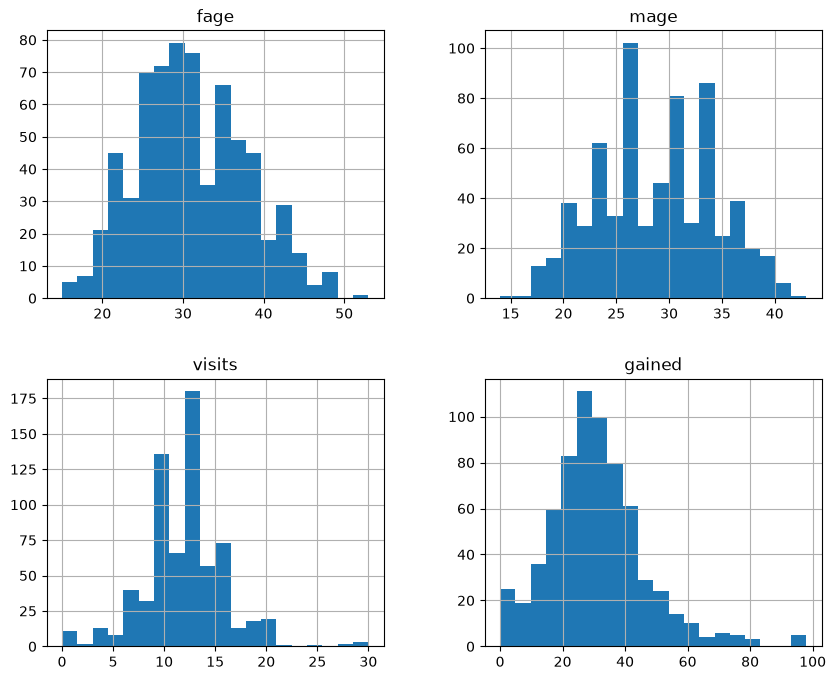

In [4]:
print("- Caracterización:")

print(predictores[["fage", "mage", "visits", "gained"]].describe())

predictores[["fage", "mage", "visits", "gained"]].hist(
    bins=20,
    figsize=(10, 8)
)

plt.show()

In [5]:
print("-- Análisis de normalidad (test de Shapiro-Wilk):")

resultado_fage = stats.shapiro(predictores["fage"])
resultado_mage = stats.shapiro(predictores["mage"])
resultado_visits = stats.shapiro(predictores["visits"])
resultado_gained = stats.shapiro(predictores["gained"])

print("- fage:", resultado_fage)
print("- mage:", resultado_mage)
print("- visits:", resultado_visits)
print("- gained:", resultado_gained)

print("\n--- Ninguno de los predictores (numéricos) sigue una distribución normal (p < 0,05). Sin embargo, tanto de los gráficos como de la comparación de las medias y medianas surge que estas variables siguen distribuciones bastante simétricas.")

-- Análisis de normalidad (test de Shapiro-Wilk):
- fage: ShapiroResult(statistic=np.float64(0.9898841425248859), pvalue=np.float64(0.00013432167432166894))
- mage: ShapiroResult(statistic=np.float64(0.9881267919068982), pvalue=np.float64(2.74203284588859e-05))
- visits: ShapiroResult(statistic=np.float64(0.9518601704272457), pvalue=np.float64(4.892563241831919e-14))
- gained: ShapiroResult(statistic=np.float64(0.9525271454777701), pvalue=np.float64(6.325174705930823e-14))

--- Ninguno de los predictores (numéricos) sigue una distribución normal (p < 0,05). Sin embargo, tanto de los gráficos como de la comparación de las medias y medianas surge que estas variables siguen distribuciones bastante simétricas.


## Predictores categóricos: mature, sex, habit, marital y whitemom

In [6]:
variables_cat = ["mature", "sex", "habit", "marital", "whitemom"]

for variable in variables_cat:
    print(predictores[variable].value_counts())
    print()

mature
younger mom    567
mature mom     108
Name: count, dtype: int64

sex
female    338
male      337
Name: count, dtype: int64

habit
nonsmoker    622
smoker        53
Name: count, dtype: int64

marital
married        450
not married    225
Name: count, dtype: int64

whitemom
white        535
not white    140
Name: count, dtype: int64



# Distribución del peso según cada predictor categórico

Importante: para los tests estadísticos se asumió homocedasticidad en todos los casos.

-- Influencia del sexo del bebé en su peso al nacer:


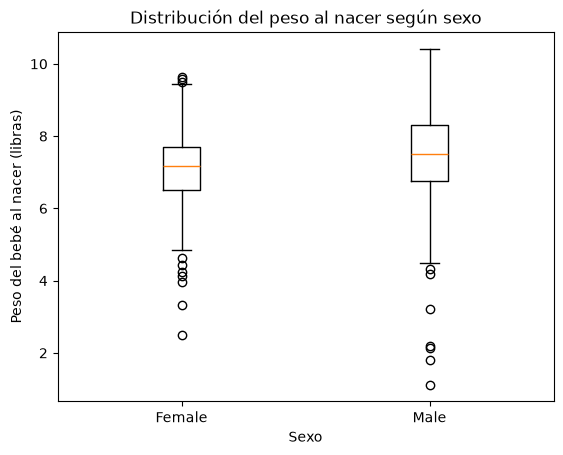

Peso según sexo:

Female:
count    338.000000
mean       7.078284
std        1.068426
min        2.500000
25%        6.500000
50%        7.160000
75%        7.690000
max        9.630000
Name: weight, dtype: float64

Male:
count    337.000000
mean       7.453709
std        1.322352
min        1.120000
25%        6.750000
50%        7.500000
75%        8.310000
max       10.420000
Name: weight, dtype: float64
- Estadístico t: -4.0575838325766185
- p-value: 5.5399189145474656e-05

Efectivamente, el peso de los varones es significativamente mayor al de las mujeres en esta muestra al momento de nacer (p < 0,001).


In [7]:
print("-- Influencia del sexo del bebé en su peso al nacer:")

plt.boxplot(
    [
        var_ind[predictores["sex"] == "female"],
        var_ind[predictores["sex"] == "male"]
    ],
    tick_labels=["Female", "Male"]
)

plt.xlabel("Sexo")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según sexo")

plt.show()

print("Peso según sexo:")

print("\nFemale:")
print(var_ind[predictores["sex"] == "female"].describe())

print("\nMale:")
print(var_ind[predictores["sex"] == "male"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["sex"] == "female"],
    var_ind[predictores["sex"] == "male"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

print("\nEfectivamente, el peso de los varones es significativamente mayor al de las mujeres en esta muestra al momento de nacer (p < 0,001).")

-- Influencia de la edad de la madre en el peso de bebé al nacer:


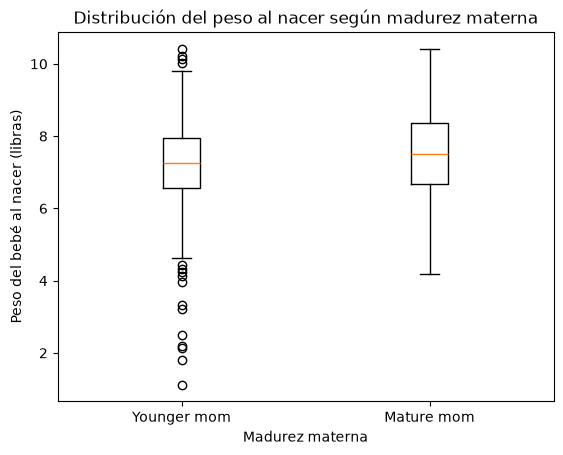

Peso según madurez materna:

Younger mom:
count    567.000000
mean       7.216684
std        1.206744
min        1.120000
25%        6.570000
50%        7.250000
75%        7.940000
max       10.420000
Name: weight, dtype: float64

Mature mom:
count    108.000000
mean       7.523148
std        1.235262
min        4.190000
25%        6.677500
50%        7.505000
75%        8.372500
max       10.410000
Name: weight, dtype: float64
- Estadístico t: -2.4097432970143
- p-value: 0.01623110664691753

Se encontraron diferencias estadísticamente significativas en el peso al nacer según la edad materna (p < 0,05). Los hijos de madres de 35 años o más presentaron un mayor peso promedio que los hijos de madres menores de 35 años.


In [8]:
print("-- Influencia de la edad de la madre en el peso de bebé al nacer:")

plt.boxplot(
    [
        var_ind[predictores["mature"] == "younger mom"],
        var_ind[predictores["mature"] == "mature mom"]
    ],
    tick_labels=["Younger mom", "Mature mom"]
)

plt.xlabel("Madurez materna")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según madurez materna")

plt.show()

print("Peso según madurez materna:")

print("\nYounger mom:")
print(var_ind[predictores["mature"] == "younger mom"].describe())

print("\nMature mom:")
print(var_ind[predictores["mature"] == "mature mom"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["mature"] == "younger mom"],
    var_ind[predictores["mature"] == "mature mom"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

print("\nSe encontraron diferencias estadísticamente significativas en el peso al nacer según la edad materna (p < 0,05). Los hijos de madres de 35 años o más presentaron un mayor peso promedio que los hijos de madres menores de 35 años.")

-- Distribución del peso según hábito de fumar:


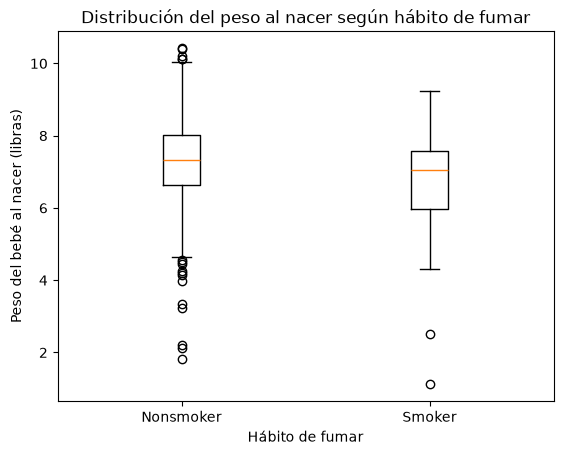

Peso según hábito de fumar:

Nonsmoker:
count    622.000000
mean       7.310707
std        1.178290
min        1.810000
25%        6.645000
50%        7.340000
75%        8.017500
max       10.420000
Name: weight, dtype: float64

Smoker:
count    53.000000
mean      6.737736
std       1.505160
min       1.120000
25%       5.960000
50%       7.060000
75%       7.580000
max       9.250000
Name: weight, dtype: float64
- Estadístico t: 3.3182777191912742
- p-value: 0.0009545248662209945

Nuevamente, el hecho de que la madre fume afecta el peso del bebé al nacer (p < 0,001). En este sentido, los bebés de madres fumadoras presentaron un peso promedio significativamente menor respecto de aquellos de madres no fumadoras.


In [9]:
print("-- Distribución del peso según hábito de fumar:")

plt.boxplot(
    [
        var_ind[predictores["habit"] == "nonsmoker"],
        var_ind[predictores["habit"] == "smoker"]
    ],
    tick_labels=["Nonsmoker", "Smoker"]
)

plt.xlabel("Hábito de fumar")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según hábito de fumar")

plt.show()

print("Peso según hábito de fumar:")

print("\nNonsmoker:")
print(var_ind[predictores["habit"] == "nonsmoker"].describe())

print("\nSmoker:")
print(var_ind[predictores["habit"] == "smoker"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["habit"] == "nonsmoker"],
    var_ind[predictores["habit"] == "smoker"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

print("\nNuevamente, el hecho de que la madre fume afecta el peso del bebé al nacer (p < 0,001). En este sentido, los bebés de madres fumadoras presentaron un peso promedio significativamente menor respecto de aquellos de madres no fumadoras.")

-- Influencia del estado civil de los progenitores en el peso del neonato:


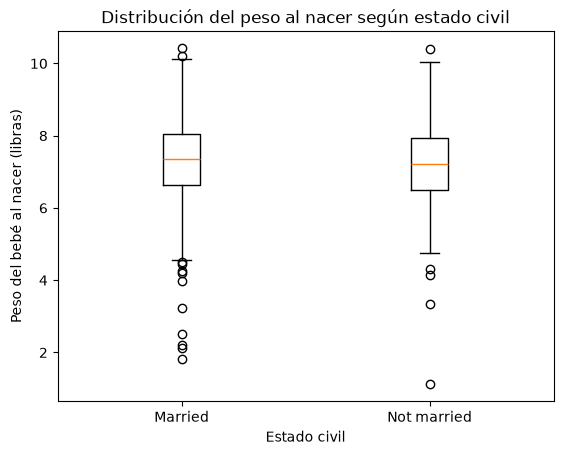

Peso según estado civil:

Married:
count    450.000000
mean       7.303111
std        1.242776
min        1.810000
25%        6.640000
50%        7.365000
75%        8.060000
max       10.420000
Name: weight, dtype: float64

Not married:
count    225.000000
mean       7.190933
std        1.158531
min        1.120000
25%        6.500000
50%        7.220000
75%        7.940000
max       10.410000
Name: weight, dtype: float64
- Estadístico t: 1.130417334578761
- p-value: 0.2587031076084956

El estado marital de la madre no afectaría el peso del bebé al nacer.


In [10]:
print("-- Influencia del estado civil de los progenitores en el peso del neonato:")

plt.boxplot(
    [
        var_ind[predictores["marital"] == "married"],
        var_ind[predictores["marital"] == "not married"]
    ],
    tick_labels=["Married", "Not married"]
)

plt.xlabel("Estado civil")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según estado civil")

plt.show()

print("Peso según estado civil:")

print("\nMarried:")
print(var_ind[predictores["marital"] == "married"].describe())

print("\nNot married:")
print(var_ind[predictores["marital"] == "not married"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["marital"] == "married"],
    var_ind[predictores["marital"] == "not married"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

print("\nEl estado marital de la madre no afectaría el peso del bebé al nacer.")

Distribución del peso según 'raza' de la madre:


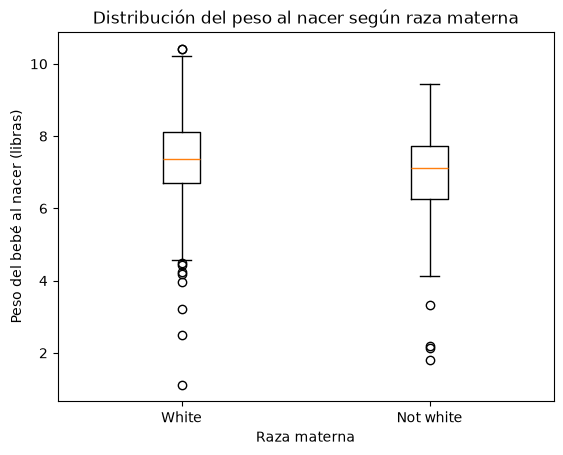

Peso según raza materna:

White:
count    535.000000
mean       7.348879
std        1.183671
min        1.120000
25%        6.690000
50%        7.370000
75%        8.125000
max       10.420000
Name: weight, dtype: float64

Not white:
count    140.000000
mean       6.947929
std        1.286348
min        1.810000
25%        6.250000
50%        7.120000
75%        7.720000
max        9.430000
Name: weight, dtype: float64
- Estadístico t: 3.5033048175358164
- p-value: 0.0004899430036055833

Se encontraron diferencias estadísticamente significativas en el peso al nacer según la categoría de raza materna. Los hijos de madres clasificadas como white presentaron un peso promedio mayor que aquellos de madres clasificadas como not white (p < 0,001).

--- En resumen: los predictores categóricos sex, mature, habit y whitemom influyen significativamente en el peso del bebé (p < 0,05). No hay evidencia suficiente para afirmar que el estado marital también lo haga.


In [11]:
print("Distribución del peso según 'raza' de la madre:")

plt.boxplot(
    [
        var_ind[predictores["whitemom"] == "white"],
        var_ind[predictores["whitemom"] == "not white"]
    ],
    tick_labels=["White", "Not white"]
)

plt.xlabel("Raza materna")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según raza materna")

plt.show()

print("Peso según raza materna:")

print("\nWhite:")
print(var_ind[predictores["whitemom"] == "white"].describe())

print("\nNot white:")
print(var_ind[predictores["whitemom"] == "not white"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["whitemom"] == "white"],
    var_ind[predictores["whitemom"] == "not white"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

print("\nSe encontraron diferencias estadísticamente significativas en el peso al nacer según la categoría de raza materna. Los hijos de madres clasificadas como white presentaron un peso promedio mayor que aquellos de madres clasificadas como not white (p < 0,001).")

print("\n--- En resumen: los predictores categóricos sex, mature, habit y whitemom influyen significativamente en el peso del bebé (p < 0,05). No hay evidencia suficiente para afirmar que el estado marital también lo haga.")

# Análisis de correlación entre los predictores (individualmente) y el peso al nacer

Edad del padre y el peso de su hijo al nacer:


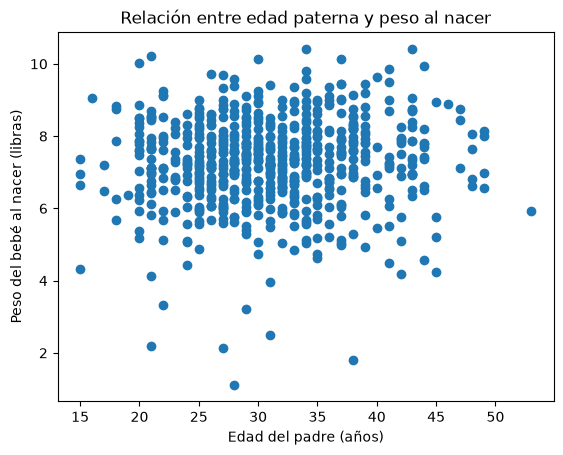

Correlación de Pearson:
- Coeficiente de correlación: 0.05962825041005415
- p-value: 0.12169613358863411

La correlación fue positiva, pero de muy baja magnitud. El p-value indica que no hay correlación lineal estadísticamente significativa.


In [12]:
print("Edad del padre y el peso de su hijo al nacer:")

plt.scatter(predictores["fage"], var_ind)

plt.xlabel("Edad del padre (años)")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Relación entre edad paterna y peso al nacer")

plt.show()

print("Correlación de Pearson:")

resultado = stats.pearsonr(predictores["fage"], var_ind)

print("- Coeficiente de correlación:", resultado.statistic)
print("- p-value:", resultado.pvalue)

print("\nLa correlación fue positiva, pero de muy baja magnitud. El p-value indica que no hay correlación lineal estadísticamente significativa.")

Edad de la madre y el peso de su hijo al nacer:


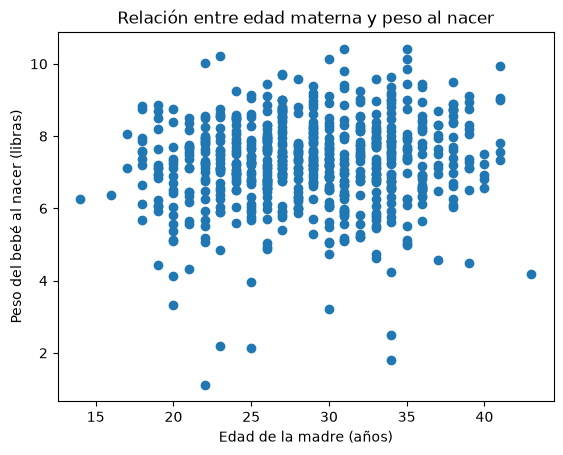

Correlación de Pearson:
- Coeficiente de correlación: 0.10420953308219373
- p-value: 0.00673225215402289
Existe una correlación positiva y estadísticamente significativa entre la edad materna y el peso promedio del bebé al nacer (p < 0,01). Sin embargo, la magnitud de la correlación fue baja, lo que indica una asociación lineal débil.


In [13]:
print("Edad de la madre y el peso de su hijo al nacer:")

plt.scatter(predictores["mage"], var_ind)

plt.xlabel("Edad de la madre (años)")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Relación entre edad materna y peso al nacer")

plt.show()

print("Correlación de Pearson:")

resultado = stats.pearsonr(predictores["mage"], var_ind)

print("- Coeficiente de correlación:", resultado.statistic)
print("- p-value:", resultado.pvalue)

print("Existe una correlación positiva y estadísticamente significativa entre la edad materna y el peso promedio del bebé al nacer (p < 0,01). Sin embargo, la magnitud de la correlación fue baja, lo que indica una asociación lineal débil.")

Relación entre el número de visitas al obstetra y el peso de su hijo al nacer:


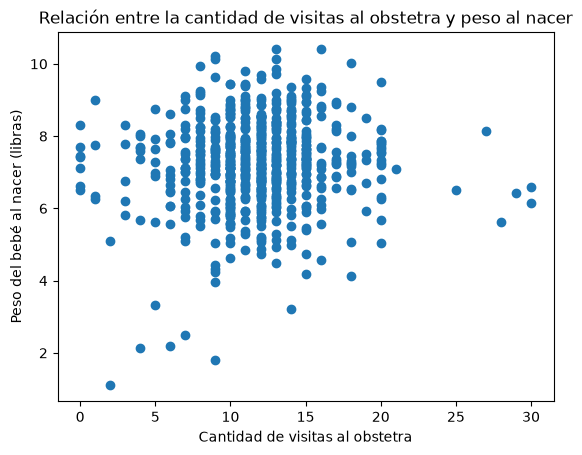

Correlación de Pearson:
- Coeficiente de correlación: 0.07485288692083707
- p-value: 0.05191254669074245
No se observó una correlación lineal estadísticamente significativa entre la cantidad de visitas al obstetra y el peso al nacer. La correlación es positiva, pero de muy baja magnitud.


In [14]:
print("Relación entre el número de visitas al obstetra y el peso de su hijo al nacer:")

plt.scatter(predictores["visits"], var_ind)

plt.xlabel("Cantidad de visitas al obstetra")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Relación entre la cantidad de visitas al obstetra y peso al nacer")

plt.show()

print("Correlación de Pearson:")

resultado = stats.pearsonr(predictores["visits"], var_ind)

print("- Coeficiente de correlación:", resultado.statistic)
print("- p-value:", resultado.pvalue)

print("No se observó una correlación lineal estadísticamente significativa entre la cantidad de visitas al obstetra y el peso al nacer. La correlación es positiva, pero de muy baja magnitud.")

Correlación entre el peso corporal ganado por la madre y el peso de su hijo al nacer:


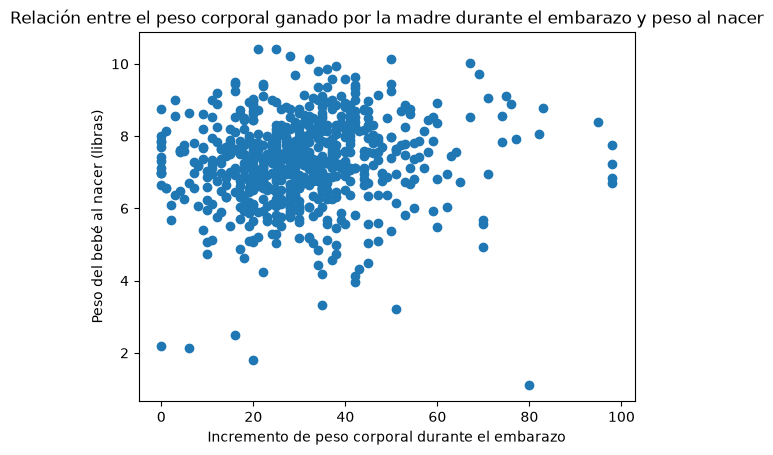

Correlación de Pearson:
- Coeficiente de correlación: 0.09928096371255103
- p-value: 0.009851641800050197
Se observó una correlación positiva y estadísticamente significativa entre el aumento de peso materno y el peso al nacer (p < 0,01). No obstante, la magnitud de la correlación fue muy baja, indicando una asociación lineal débil entre ambas variables.


In [15]:
print("Correlación entre el peso corporal ganado por la madre y el peso de su hijo al nacer:")

plt.scatter(predictores["gained"], var_ind)

plt.xlabel("Incremento de peso corporal durante el embarazo")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Relación entre el peso corporal ganado por la madre durante el embarazo y peso al nacer")

plt.show()

print("Correlación de Pearson:")

resultado = stats.pearsonr(predictores["gained"], var_ind)

print("- Coeficiente de correlación:", resultado.statistic)
print("- p-value:", resultado.pvalue)

print("Se observó una correlación positiva y estadísticamente significativa entre el aumento de peso materno y el peso al nacer (p < 0,01). No obstante, la magnitud de la correlación fue muy baja, indicando una asociación lineal débil entre ambas variables.")

# Gráficos 3D: peso del bebé vs combinaciones de variables numéricas

En cada gráfico, el **eje Y es el peso del bebé al nacer** y los ejes X y Z son dos variables no categóricas. Con 4 variables numéricas (`fage`, `mage`, `visits`, `gained`) hay 6 combinaciones posibles. Los puntos se colorean según el peso.

In [24]:
etiquetas_3d = {
    "fage": "Edad del padre (años)",
    "mage": "Edad de la madre (años)",
    "visits": "Cantidad de visitas al obstetra",
    "gained": "Aumento de peso materno (libras)",
}

def grafico_3d(var_x, var_z):
    datos = pd.concat(
        [predictores[[var_x, var_z]], var_ind.rename("weight")],
        axis=1
    ).dropna()

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection="3d")

    puntos = ax.scatter(
        datos[var_x],
        datos["weight"],
        datos[var_z],
        c=datos["weight"],
        cmap="viridis",
        s=15,
        alpha=0.6
    )

    fig.colorbar(puntos, ax=ax, shrink=0.6, label="Peso del bebé al nacer (libras)")

    ax.set_xlabel(etiquetas_3d[var_x])
    ax.set_ylabel("Peso del bebé al nacer (libras)")
    ax.set_zlabel(etiquetas_3d[var_z])
    ax.set_title(f"Peso al nacer según {var_x} y {var_z}")

    ax.view_init(elev=20, azim=-60)
    plt.show()

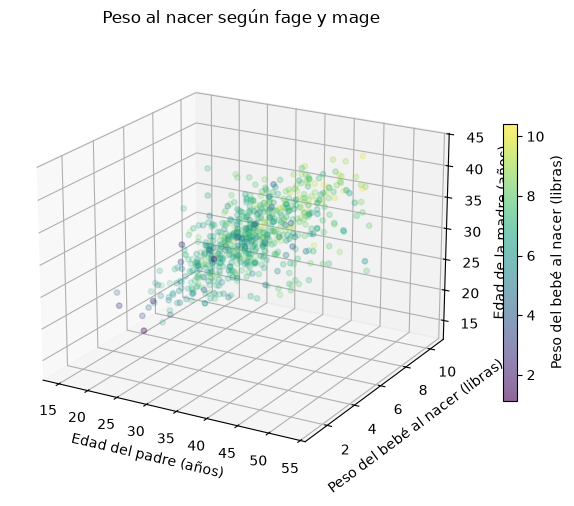

In [17]:
grafico_3d("fage", "mage")

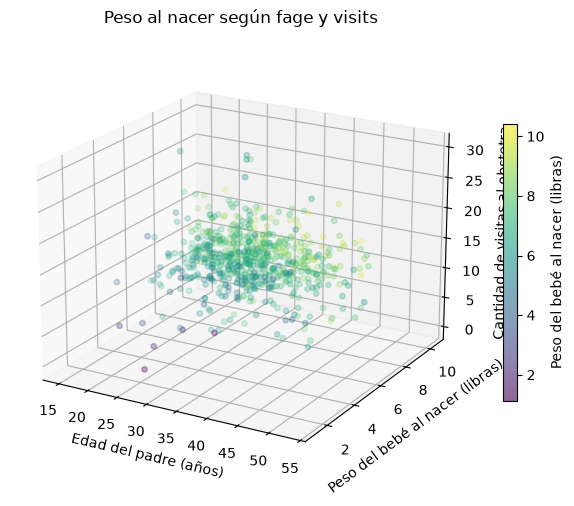

In [18]:
grafico_3d("fage", "visits")

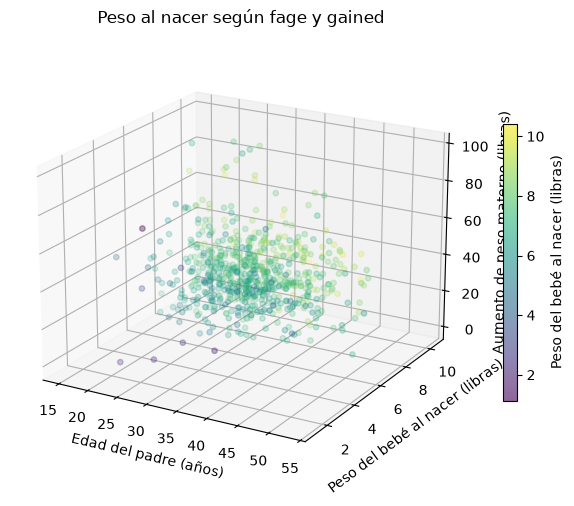

In [19]:
grafico_3d("fage", "gained")

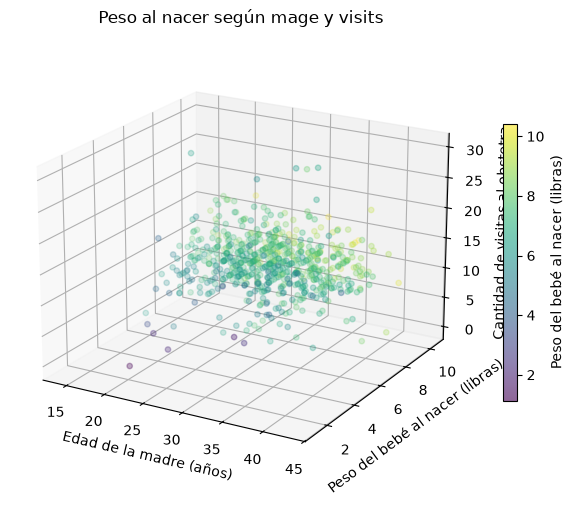

In [20]:
grafico_3d("mage", "visits")

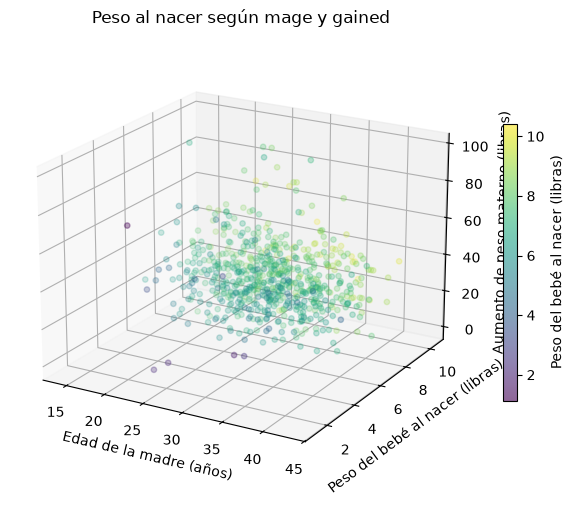

In [21]:
grafico_3d("mage", "gained")

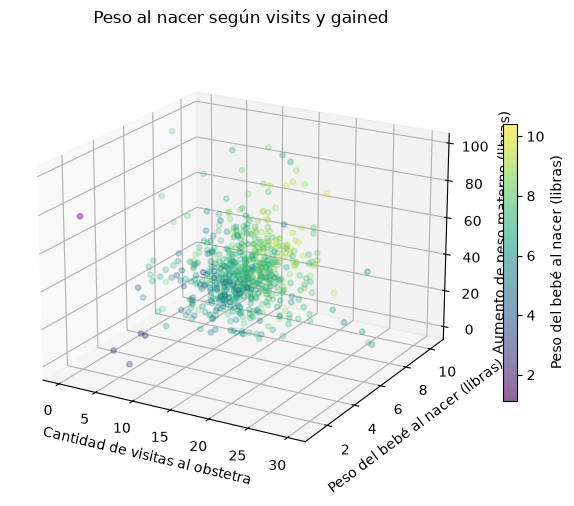

In [22]:
grafico_3d("visits", "gained")

# Gráficos 3D interactivos (plotly)

Versiones interactivas de los gráficos anteriores, con las mismas 6 combinaciones de variables numéricas (eje Y = peso del bebé). Se pueden rotar (arrastrando), hacer zoom (scroll) y ver los valores de cada punto pasando el mouse.

In [25]:
import plotly.express as px

def grafico_3d_interactivo(var_x, var_z):
    datos = pd.concat(
        [predictores[[var_x, var_z]], var_ind.rename("weight")],
        axis=1
    ).dropna()

    fig = px.scatter_3d(
        datos,
        x=var_x,
        y="weight",
        z=var_z,
        color="weight",
        color_continuous_scale="viridis",
        opacity=0.6,
    )

    fig.update_traces(marker=dict(size=3))

    fig.update_layout(
        scene=dict(
            xaxis_title=etiquetas_3d[var_x],
            yaxis_title="Peso del bebé al nacer (libras)",
            zaxis_title=etiquetas_3d[var_z],
        ),
        coloraxis_colorbar=dict(title="Peso (libras)"),
        margin=dict(l=0, r=0, b=0, t=40),
        height=700,
    )

    return fig

In [26]:
grafico_3d_interactivo("fage", "mage")

In [27]:
grafico_3d_interactivo("fage", "visits")

In [28]:
grafico_3d_interactivo("fage", "gained")

In [29]:
grafico_3d_interactivo("mage", "visits")

In [30]:
grafico_3d_interactivo("mage", "gained")

In [31]:
grafico_3d_interactivo("visits", "gained")

# Gráficos 3D con el peso como color

A diferencia de las secciones anteriores, el peso no ocupa ningún eje: los tres ejes son variables numéricas (las 4 tripletas posibles entre `fage`, `mage`, `visits` y `gained`) y el color de cada punto representa el peso del bebé al nacer.

In [42]:
def grafico_3d_color(var_x, var_y, var_z):
    datos = pd.concat(
        [predictores[[var_x, var_y, var_z]], var_ind.rename("weight")],
        axis=1
    ).dropna()

    fig = px.scatter_3d(
        datos,
        x=var_x,
        y=var_y,
        z=var_z,
        color="weight",
        color_continuous_scale=px.colors.sequential.Viridis_r,
        opacity=0.6,
    )

    fig.update_traces(marker=dict(size=3))

    fig.update_layout(
        scene=dict(
            xaxis_title=etiquetas_3d[var_x],
            yaxis_title=etiquetas_3d[var_y],
            zaxis_title=etiquetas_3d[var_z],
        ),
        coloraxis_colorbar=dict(title="Peso (libras)"),
        margin=dict(l=0, r=0, b=0, t=40),
        height=700,
    )

    return fig

In [43]:
grafico_3d_color("fage", "mage", "visits")

In [44]:
grafico_3d_color("fage", "mage", "gained")

In [45]:
grafico_3d_color("fage", "visits", "gained")

In [46]:
grafico_3d_color("mage", "visits", "gained")